In [6]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


In [3]:
def simulate_ramsey(T, T2, n_points=200):
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    psi0 = qt.basis(2, 0)
    pi_half_y = (-1j *(np.pi/4)*sy).expm()
    psi_after_plus = pi_half_y * psi0

    H = 0 * sz
    gamma_dephasing = 1.0 / T2
    c_ops = [np.sqrt(gamma_dephasing /2 )* sz]

    times = np.linspace(0, T, n_points)
    result = qt.mesolve(H, psi_after_plus, times, c_ops, e_ops=[sx, sy])

    coherence = np.sqrt(result.expect[0]**2 + result.expect[1]**2)
    return times, coherence



In [4]:
def simulate_hahn_echo(T, T2, n_points=200):
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    psi0 = qt.basis(2, 0)
    pi_half_y = (-1j * (np.pi/4) *sy).expm()
    pi_pulse_x = (-1j * (np.pi/2) *sx).expm()

    psi_after_pulse = pi_half_y * psi0
    gamma_dephasing = 1.0 / T2
    c_ops = [np.sqrt(gamma_dephasing /2) * sz]
    H = 0 * sz

    t_half = np.linspace(0, T /2, n_points //2)
    result1 = qt.mesolve(H, psi_after_pulse, t_half, c_ops, e_ops=[])
    rho_mid = result1.states[-1]
    rho_after_pulse = pi_pulse_x * rho_mid * pi_pulse_x.dag()

    result2 = qt.mesolve(H, rho_after_pulse, t_half, c_ops, e_ops=[sx, sy])
    coherence = np.sqrt(result2.expect[0]**2 + result2.expect[1]**2)
    times = T /2 + t_half

    return np.concatenate([t_half, times]), None, coherence

Saved qutip_verification.png -- compare the two curves.


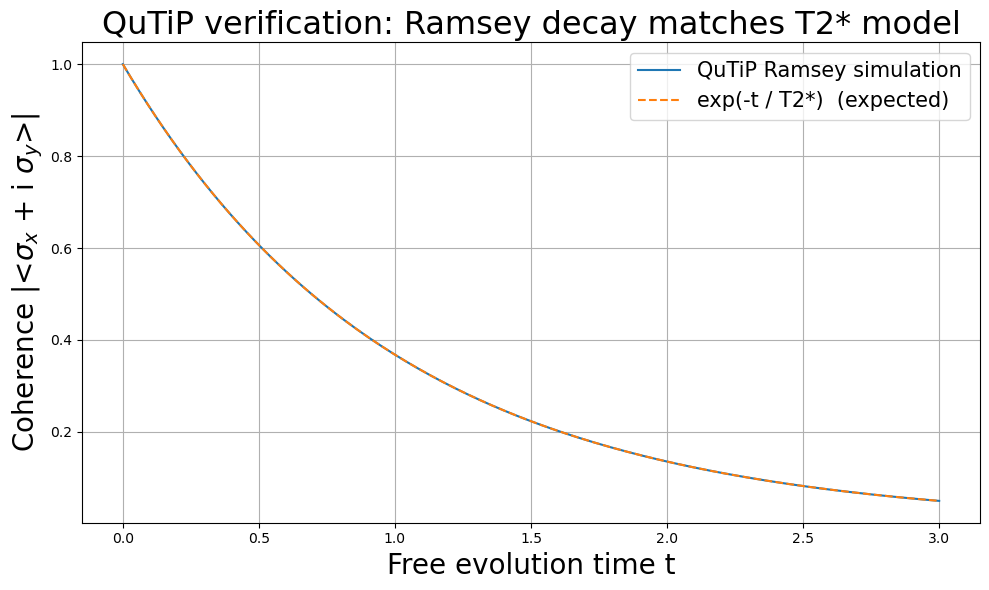

In [11]:
T2 = 1.0
times, coherence = simulate_ramsey(T=3.0, T2=T2)
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(times, coherence, label="QuTiP Ramsey simulation")
ax.plot(times, np.exp(-times / T2), "--", label="exp(-t / T2*)  (expected)")
ax.set_xlabel("Free evolution time t", fontsize=20)
ax.set_ylabel("Coherence |<$\sigma_x$ + i $\sigma_y$>|", fontsize=20)
ax.legend(fontsize=15)
ax.grid(True)
ax.set_title("QuTiP verification: Ramsey decay matches T2* model", fontsize=23)
fig.tight_layout()
#fig.savefig("qutip_verification.png", dpi=150)
print("Saved qutip_verification.png -- compare the two curves.")